The 4 Cs of Diamonds:-

carat (0.2--5.01) The carat is the diamond’s physical weight measured in metric carats. One carat equals 1/5 gram and is subdivided into 100 points. Carat weight is the most objective grade of the 4Cs.

cut (Fair, Good, Very Good, Premium, Ideal) In determining the quality of the cut, the diamond grader evaluates the cutter’s skill in the fashioning of the diamond. The more precise the diamond is cut, the more captivating the diamond is to the eye.

color, from J (worst) to D (best) The colour of gem-quality diamonds occurs in many hues. In the range from colourless to light yellow or light brown. Colourless diamonds are the rarest. Other natural colours (blue, red, pink for example) are known as "fancy,” and their colour grading is different than from white colorless diamonds.

clarity (I1 (worst), SI2, SI1, VS2, VS1, VVS2, VVS1, IF (best)) Diamonds can have internal characteristics known as inclusions or external characteristics known as blemishes. Diamonds without inclusions or blemishes are rare; however, most characteristics can only be seen with magnification.

Dimensions

x length in mm (0--10.74)

y width in mm (0--58.9)

z depth in mm (0--31.8)

depth total depth percentage = z / mean(x, y) = 2 * z / (x + y) (43--79)

table width of top of diamond relative to widest point (43--95)

In [8]:
#https://www.kaggle.com/datasets/shivam2503/diamonds
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("10-diamonds.csv")

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  str    
 3   color       53940 non-null  str    
 4   clarity     53940 non-null  str    
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), str(3)
memory usage: 4.5 MB


In [10]:
df = df.drop("Unnamed: 0", axis=1)
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [ ]:
df.describe()
# we know x,y,z represents dimensions but we see min 0 in x,y,z so they are most probably faulty data

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [12]:
df.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

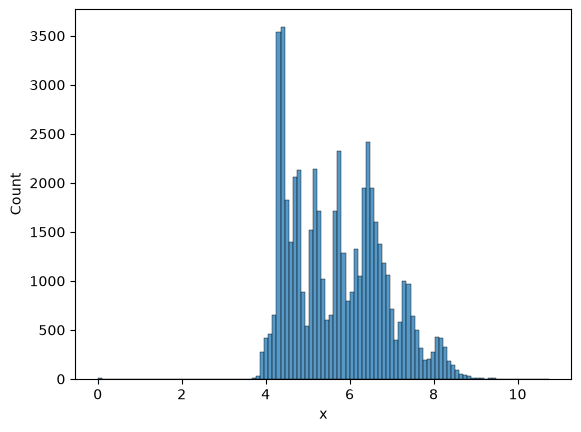

In [13]:
sns.histplot(df["x"])
plt.show()

In [ ]:
df[df["x"] == 0].count() #8
df[df["x"] == 0]

,carat,cut,color,clarity,depth,table,price,x,y,z
11182,1.07,Ideal,F,SI2,61.6,56.0,4954,0.0,6.62,0.0
11963,1.00,Very Good,H,VS2,63.3,53.0,5139,0.0,0.00,0.0
15951,1.14,Fair,G,VS1,57.5,67.0,6381,0.0,0.00,0.0
24520,1.56,Ideal,G,VS2,62.2,54.0,12800,0.0,0.00,0.0
26243,1.20,Premium,D,VVS1,62.1,59.0,15686,0.0,0.00,0.0
27429,2.25,Premium,H,SI2,62.8,59.0,18034,0.0,0.00,0.0
49556,0.71,Good,F,SI2,64.1,60.0,2130,0.0,0.00,0.0
49557,0.71,Good,F,SI2,64.1,60.0,2130,0.0,0.00,0.0


In [22]:
len(df[df["x"] == 0]), len(df[df["y"] == 0]), len(df[df["z"] == 0])

(8, 7, 20)

In [25]:
df = df.drop(df[df["x"]==0].index)
df = df.drop(df[df["y"]==0].index)
df = df.drop(df[df["z"]==0].index)

In [26]:
len(df[df["x"] == 0]), len(df[df["y"] == 0]), len(df[df["z"] == 0])


(0, 0, 0)

HANDLING OUTLIERS

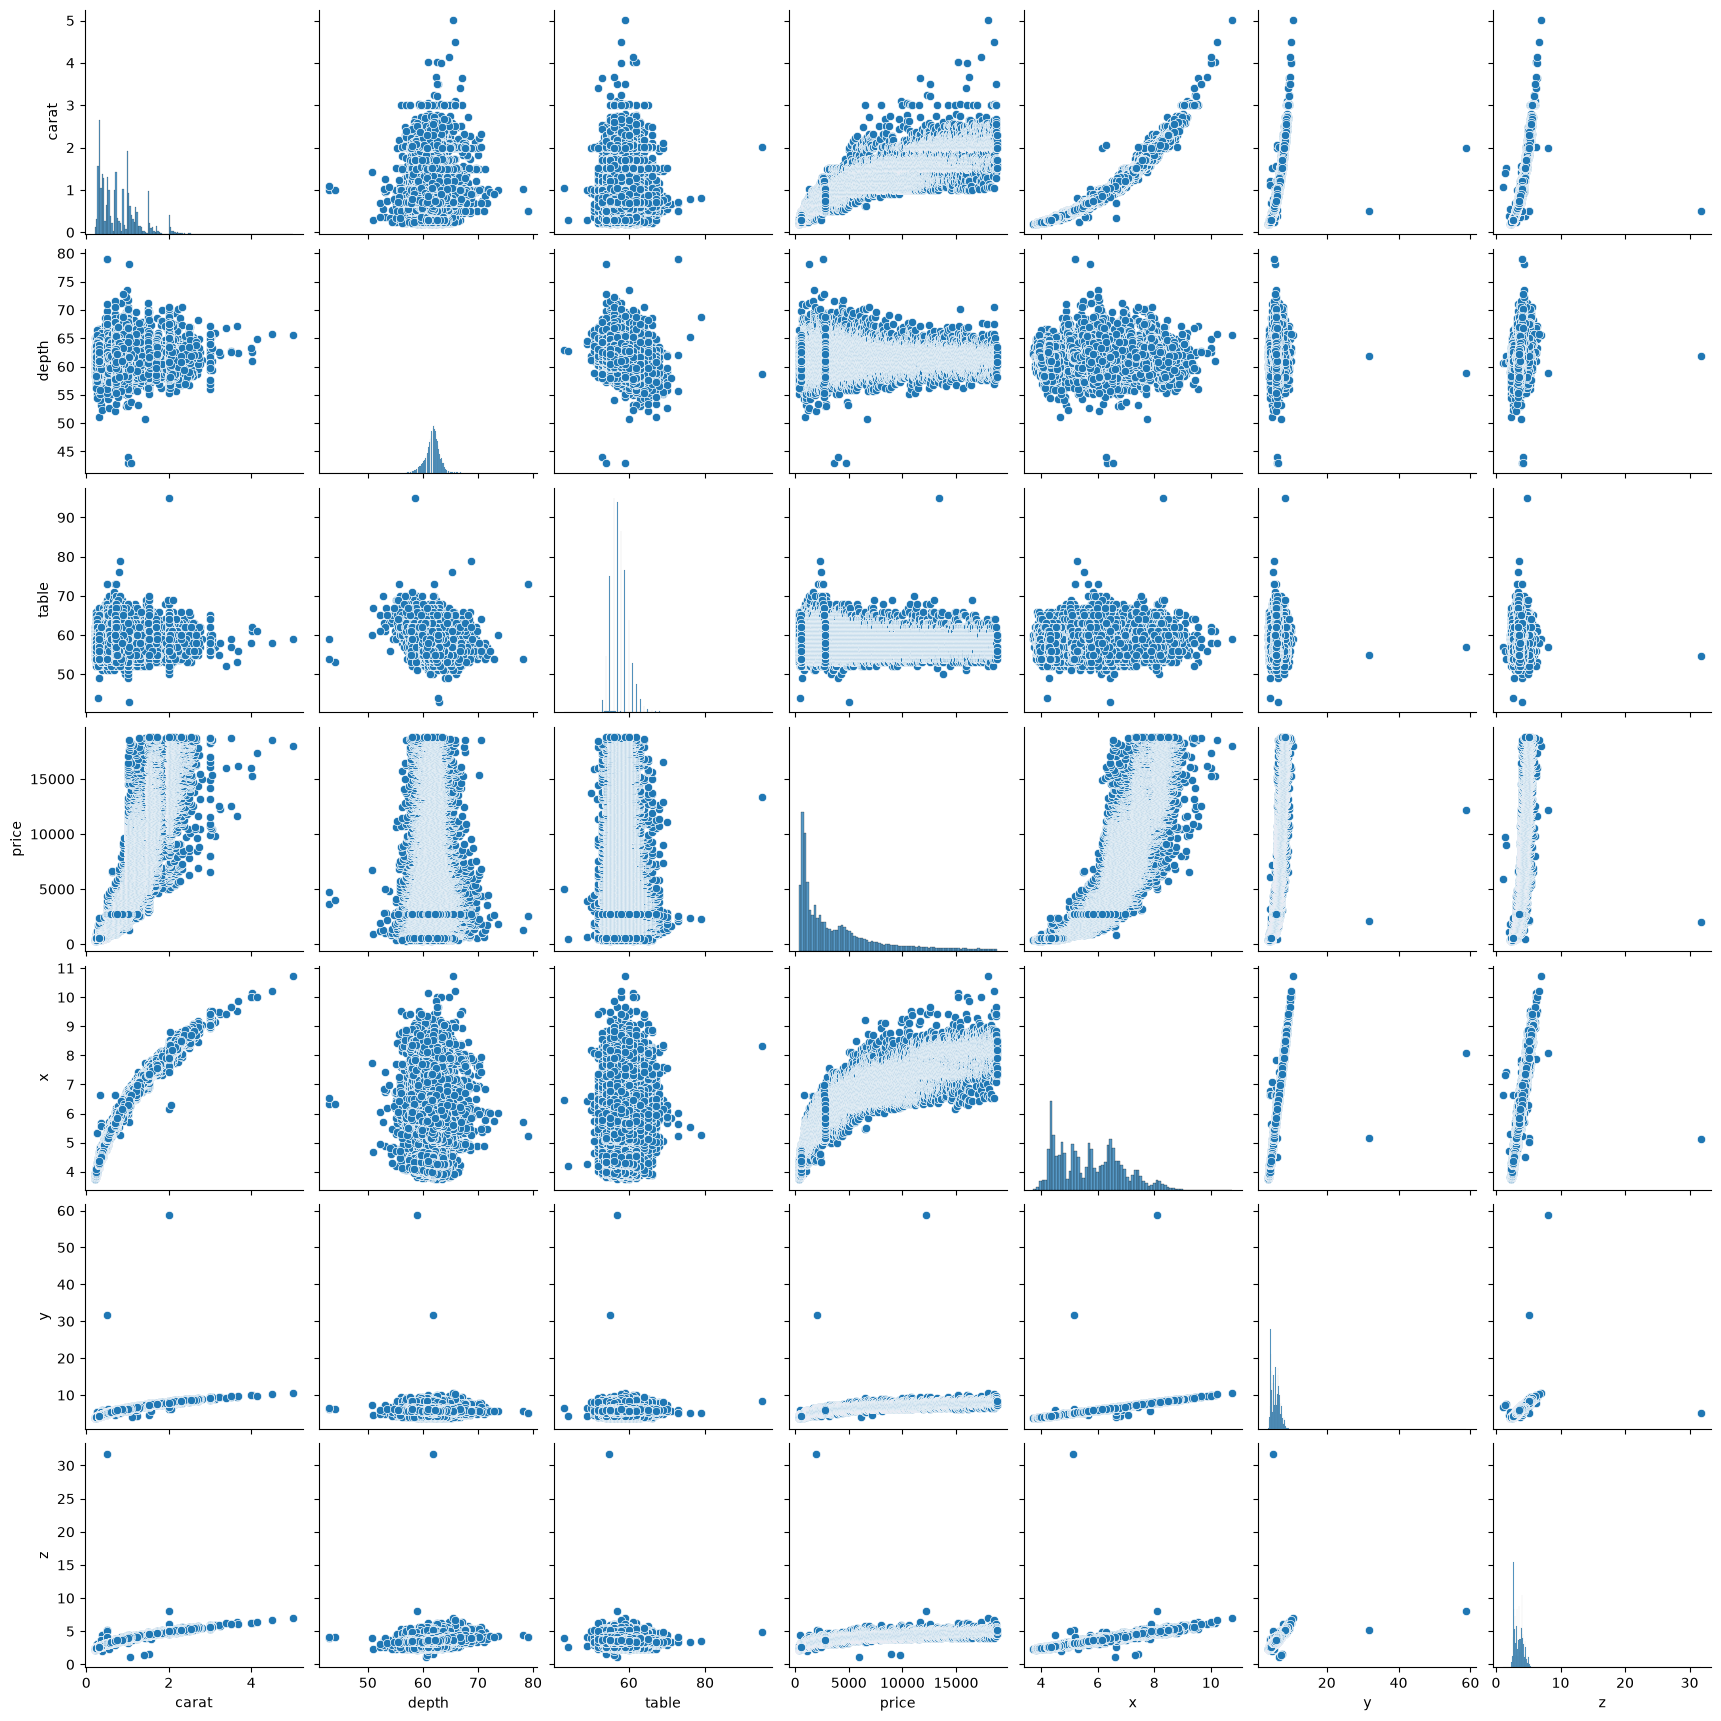

In [29]:
sns.pairplot(df)
plt.show()

<Axes: xlabel='x', ylabel='price'>

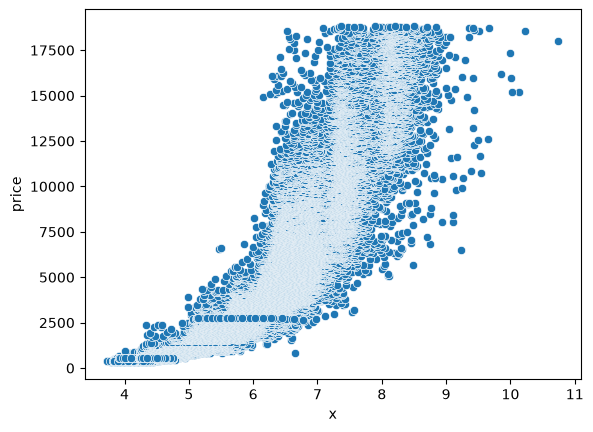

In [32]:
sns.scatterplot(x=df["x"], y=df["price"])

<Axes: xlabel='y', ylabel='price'>

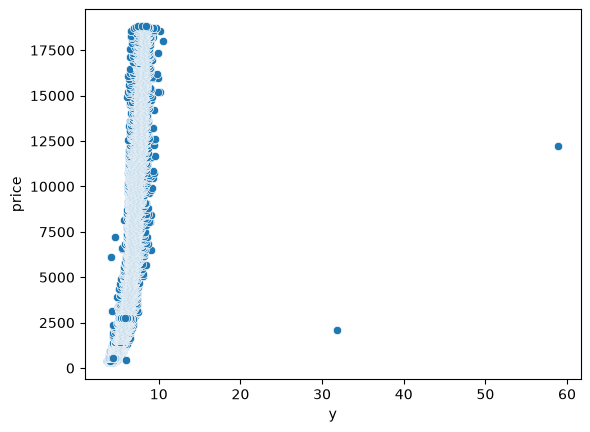

In [ ]:
sns.scatterplot(x=df["y"], y=df["price"]) #there are clear outliers in y versus price


<Axes: xlabel='z', ylabel='price'>

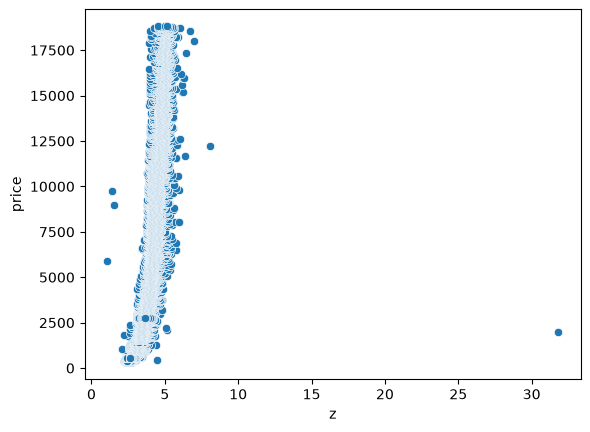

In [ ]:
sns.scatterplot(x=df["z"], y=df["price"]) #there are outliers in z as well


<Axes: xlabel='table', ylabel='price'>

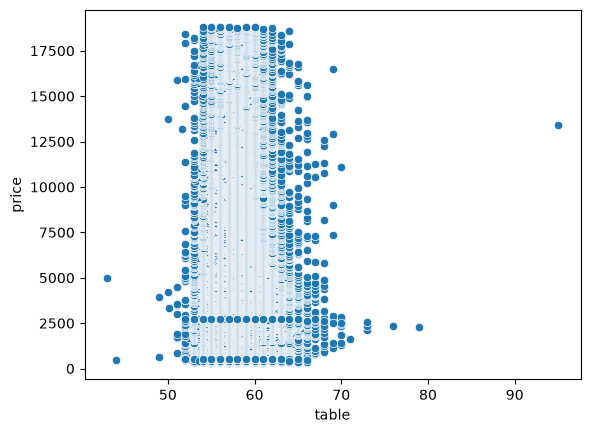

In [ ]:
sns.scatterplot(x=df["table"], y=df["price"])# there are outliers over here that might affect the outcome


<Axes: xlabel='depth', ylabel='price'>

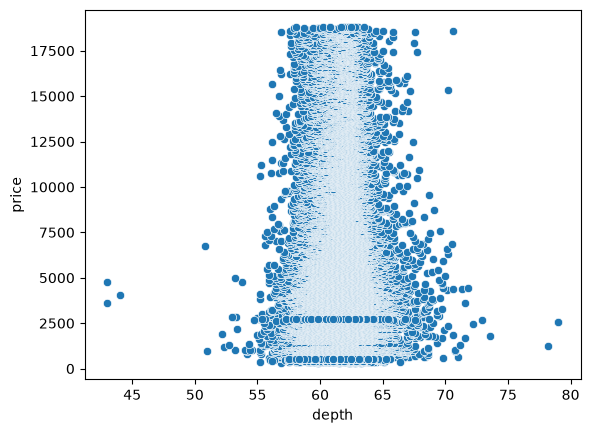

In [ ]:
sns.scatterplot(x=df["depth"], y=df["price"])
# there are some outliers over here as well, just by looking at the graphs we can eliminate outliers easily

In [37]:
df = df[(df["depth"] < 75) & (df["depth"] > 45 )]
df = df[(df["table"] < 75) & (df["table"] > 40 )]
df = df[(df["z"] < 30) & (df["z"] > 2 )]
df = df[(df["y"] < 20)]

In [38]:
df.describe()

,carat,depth,table,price,x,y,z
count,53905.000000,53905.000000,53905.000000,53905.000000,53905.000000,53905.000000,53905.000000
mean,0.797628,61.749545,57.455205,3930.643799,5.731476,5.733313,3.539443
std,0.473774,1.419739,2.222825,3987.264881,1.119402,1.111267,0.691446
min,0.200000,50.800000,43.000000,326.000000,3.730000,3.680000,2.060000
25%,0.400000,61.000000,56.000000,949.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5322.000000,6.540000,6.540000,4.040000
max,5.010000,73.600000,73.000000,18823.000000,10.740000,10.540000,6.980000


    ENCODING & SCALING  

In [39]:
df["cut"].value_counts()

cut
Ideal        21543
Premium      13779
Very Good    12080
Good          4902
Fair          1601
Name: count, dtype: int64

In [44]:
df["color"].value_counts()

color
G    11281
E     9792
F     9535
H     8296
D     6774
I     5420
J     2807
Name: count, dtype: int64

In [45]:
#before encoding these, i will split this into train-test to avoid data leakage
X = df.drop("price", axis=1)
y = df["price"]

In [48]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state= 15)
X.head()

,carat,cut,color,clarity,depth,table,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,4.34,4.35,2.75


In [47]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

In [49]:
for col in ["cut", "color", "clarity"]:
    X_train[col] = label_encoder.fit_transform(X_train[col])
    X_test[col] = label_encoder.transform(X_test[col])

In [50]:
X_train.head()

,carat,cut,color,clarity,depth,table,x,y,z
15200,1.15,2,4,2,62.4,54.0,6.71,6.76,4.20
14632,1.11,3,1,2,61.3,58.0,6.66,6.61,4.07
19151,1.21,1,2,5,63.7,58.0,6.67,6.71,4.26
29299,0.30,2,5,5,61.5,58.0,4.28,4.31,2.64
9983,1.00,4,2,2,63.1,57.0,6.37,6.33,4.01


In [52]:
X_train["cut"].value_counts()

cut
2    16164
3    10371
4     9018
1     3684
0     1191
Name: count, dtype: int64

In [53]:
# model training
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

    LINEER REGRESSION

In [55]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Mean absolute error 867.7716773299012
R2 Score 0.8686521594180446


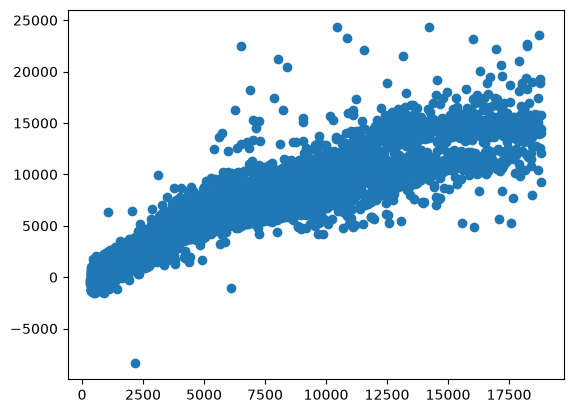

In [ ]:
linear = LinearRegression()
linear.fit(X_train_scaled, y_train)
y_pred = linear.predict(X_test_scaled)

mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
score = r2_score(y_test,y_pred)

print("Mean absolute error: ", mae)
print("Mean squared error: ", mse)
print("R2 Score: ", score)
plt.scatter(y_test,y_pred)
plt.show()

    SVM REGRESSION

Mean absolute error 1397.853335232954
R2 Score -1.4456496874568576


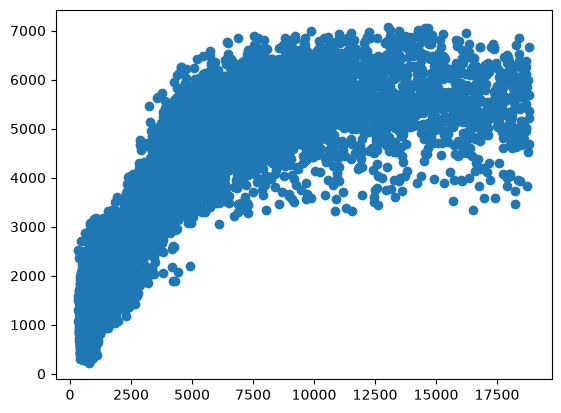

In [ ]:
from sklearn.svm import SVR
svr = SVR()
svr.fit(X_train_scaled,y_train)
y_pred = svr.predict(X_test_scaled)

mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
score = r2_score(y_test,y_pred)

print("Mean absolute error: ", mae)
print("Mean squared error: ", mse)
print("R2 Score: ", score)
plt.scatter(y_test,y_pred)
plt.show()

    HYPERPARAMETER TUNING

In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    "C" : [0.1, 1 ,10, 100, 1000],
    "gamma" : [1, 0.1, 0.001],
    "kernel" : ['linear','rbf']
}

grid = GridSearchCV(estimator= SVR(), param_grid= param_grid, n_jobs= -1, verbose=3)

In [ ]:
#commented cuz takes too long
#grid.fit(X_train_scaled, y_train)

In [ ]:
grid.best_params_

In [ ]:
y_pred=grid.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)
plt.scatter(y_test,y_pred)
plt.show()